# ***Python DA Assignment 2 - Data Visualization***

### **1) Loading the Taxis Dataset**

In [1]:
import seaborn as sns
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

In [4]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [5]:
df.tail()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn
6432,2019-03-13 19:31:22,2019-03-13 19:48:02,1,3.85,15.0,3.36,0.0,20.16,green,credit card,Boerum Hill,Windsor Terrace,Brooklyn,Brooklyn


In [7]:
df.shape

(6433, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

### **2) Handling Missing Values**

#### ***Check for missing values***

In [ ]:
nul_col = df.isna().sum()
nul_col

In [20]:
nul_col[nul_col > 0]

,0
payment,44
pickup_zone,26
dropoff_zone,45
pickup_borough,26
dropoff_borough,45


#### ***Impute missing values***

In [29]:
mode_col = ['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']
mode_col

['payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough', 'dropoff_borough']

In [30]:
for col in mode_col:
    df[col] = df[col].fillna(df[col].mode()[0])

In [31]:
nul_col = df.isna().sum()
nul_col

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


### **3) Visualizations using Matplotlib/Pandas Plot:**

In [39]:
numerical_col = df.select_dtypes('number').columns.to_list()
numerical_col

['passengers', 'distance', 'fare', 'tip', 'tolls', 'total']

In [27]:
df[numerical_col].describe().astype(int)

,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433,6433,6433,6433
mean,1,3,13,1,0,18
std,1,3,11,2,1,13
min,0,0,1,0,0,1
25%,1,0,6,0,0,10
50%,1,1,9,1,0,14
75%,2,3,15,2,0,20
max,6,36,150,33,24,174


In [36]:
import matplotlib.pyplot as plt
import pandas as pd

###**★ Line Chart**

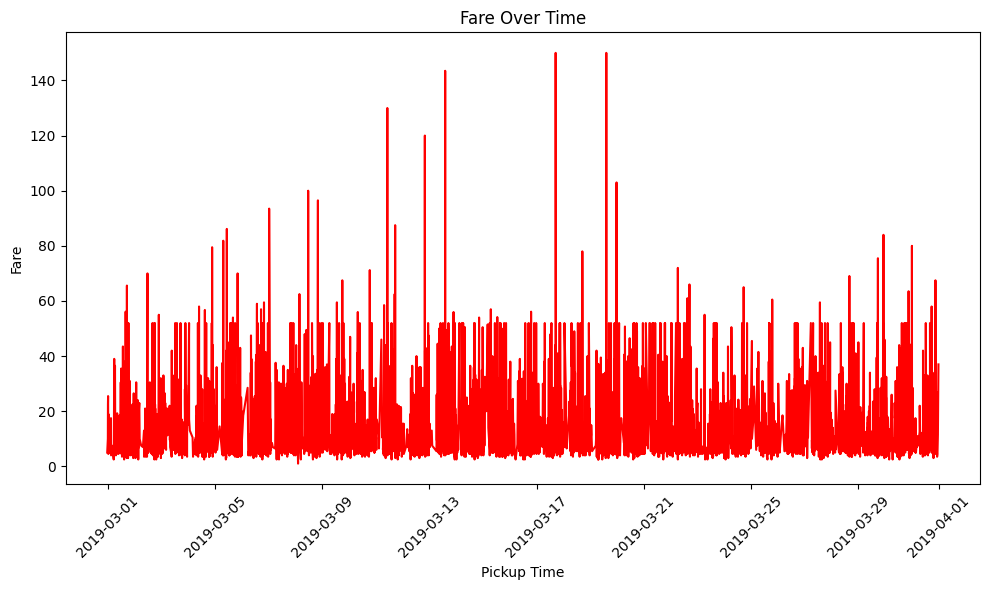

In [49]:
df['pickup'] = pd.to_datetime(df['pickup'])

df = df.sort_values('pickup')

plt.figure(figsize=(10, 6))

plt.plot(df['pickup'], df['fare'], color='r')

plt.title('Fare Over Time')
plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **★ Bar Chart**

In [45]:
bar_df = df.groupby('pickup_borough')['fare'].sum().reset_index()
bar_df

,pickup_borough,fare
0,Bronx,2078.91
1,Brooklyn,6327.48
2,Manhattan,59426.42
3,Queens,16382.06


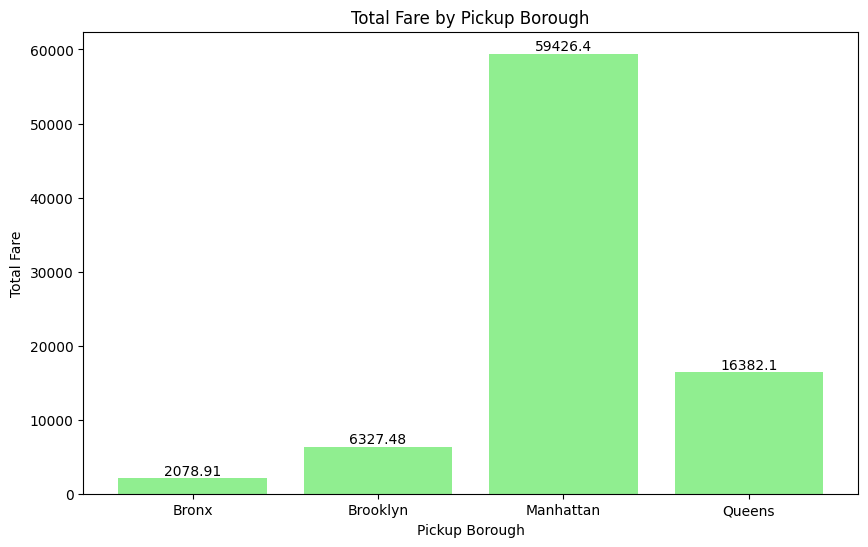

In [55]:
plt.figure(figsize=(10, 6))

b = plt.bar(bar_df['pickup_borough'], bar_df['fare'], color='lightgreen')
plt.bar_label(b)
plt.title('Total Fare by Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')
plt.show()

### **★ Pie Chart**

In [59]:
payment_counts = df['payment'].value_counts()
payment_counts

,count
payment,
credit card,4621
cash,1812


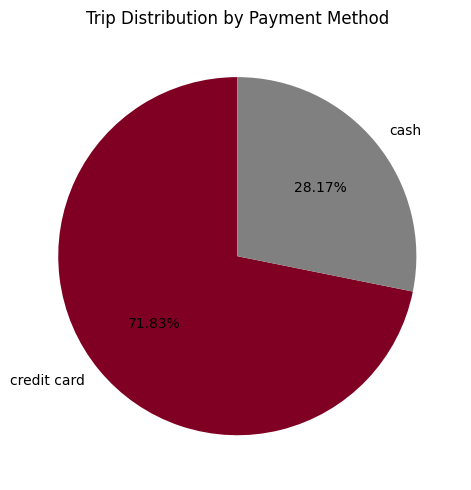

In [120]:
plt.figure(figsize=(5, 5))

plt.pie(payment_counts.values, labels=payment_counts.index, colors=['#800023','Grey'],autopct='%1.2f%%', startangle=90)

plt.title('Trip Distribution by Payment Method')
plt.tight_layout()
plt.show()

### **★ Histogram**

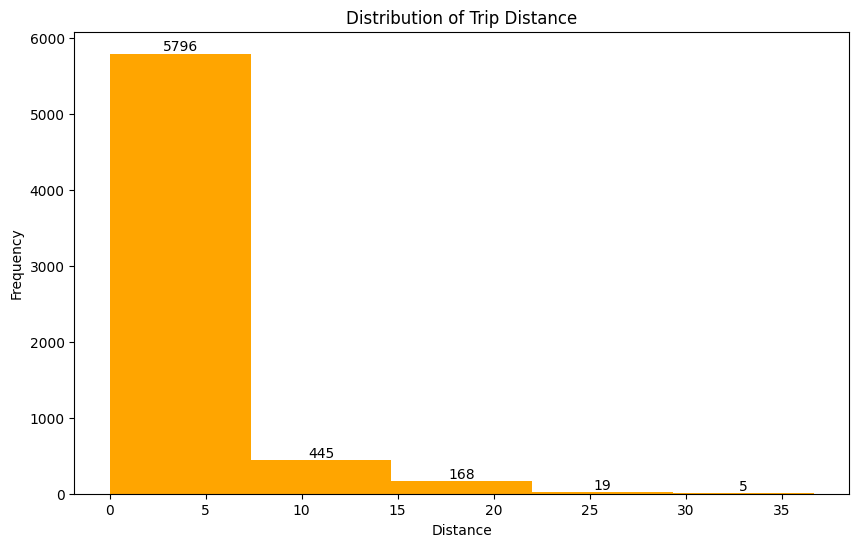

In [78]:
plt.figure(figsize=(10,6))

h = plt.hist(df['distance'], bins=5,color='orange')
plt.bar_label(h[2])
plt.title('Distribution of Trip Distance')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.show()

### **★ Box Plot**

<Figure size 1000x600 with 0 Axes>

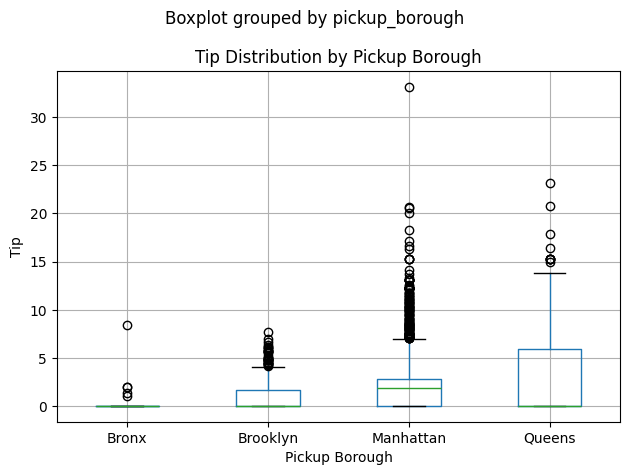

In [82]:
df.boxplot(column='tip',by='pickup_borough')

plt.title('Tip Distribution by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip')
plt.tight_layout()
plt.show()

## **4) Visualizations using Seaborn**

### **★ Count Plot**

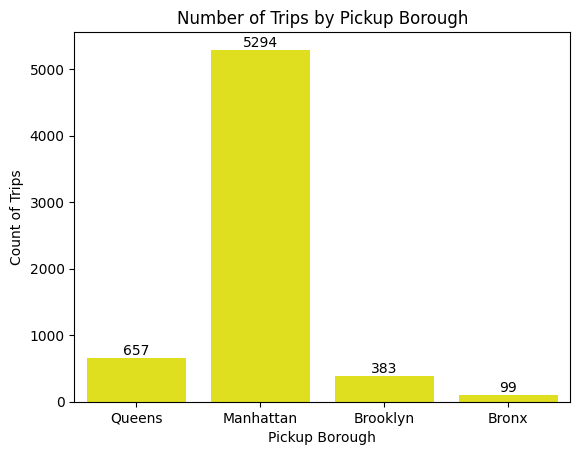

In [88]:
co = sns.countplot(data=df, x='pickup_borough', color='yellow')
co.bar_label(co.containers[0])

plt.title('Number of Trips by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Count of Trips')
plt.show()

### **★ Scatter Plot**

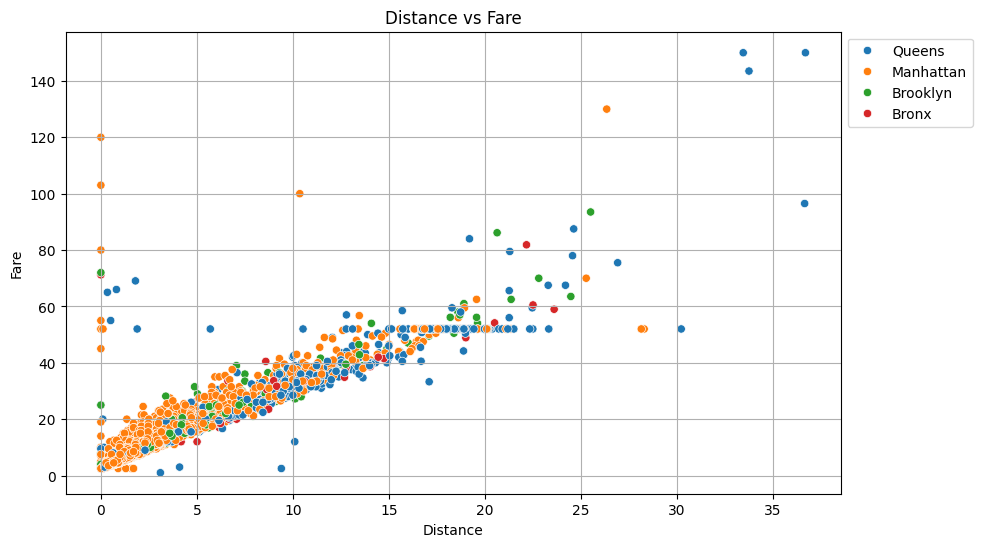

In [95]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='distance', y='fare', hue='pickup_borough')

plt.title('Distance vs Fare')
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.legend(bbox_to_anchor=(1,1))
plt.grid(True)
plt.show()

### **★ Heatmap**

In [98]:
cor = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()
cor

,distance,fare,tip,tolls,total
distance,1.000000,0.920108,0.452589,0.635267,0.904676
fare,0.920108,1.000000,0.488612,0.609307,0.974358
tip,0.452589,0.488612,1.000000,0.413619,0.646186
tolls,0.635267,0.609307,0.413619,1.000000,0.683142
total,0.904676,0.974358,0.646186,0.683142,1.000000


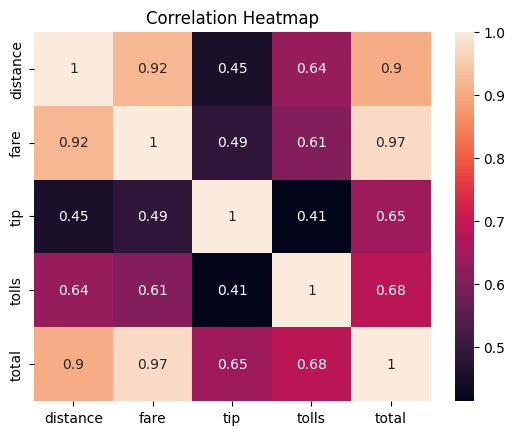

In [101]:
sns.heatmap(cor, annot=True)

plt.title('Correlation Heatmap')
plt.show()

### **★ Pair Plot**

/tmp/ipykernel_1469/90333206.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1,1))


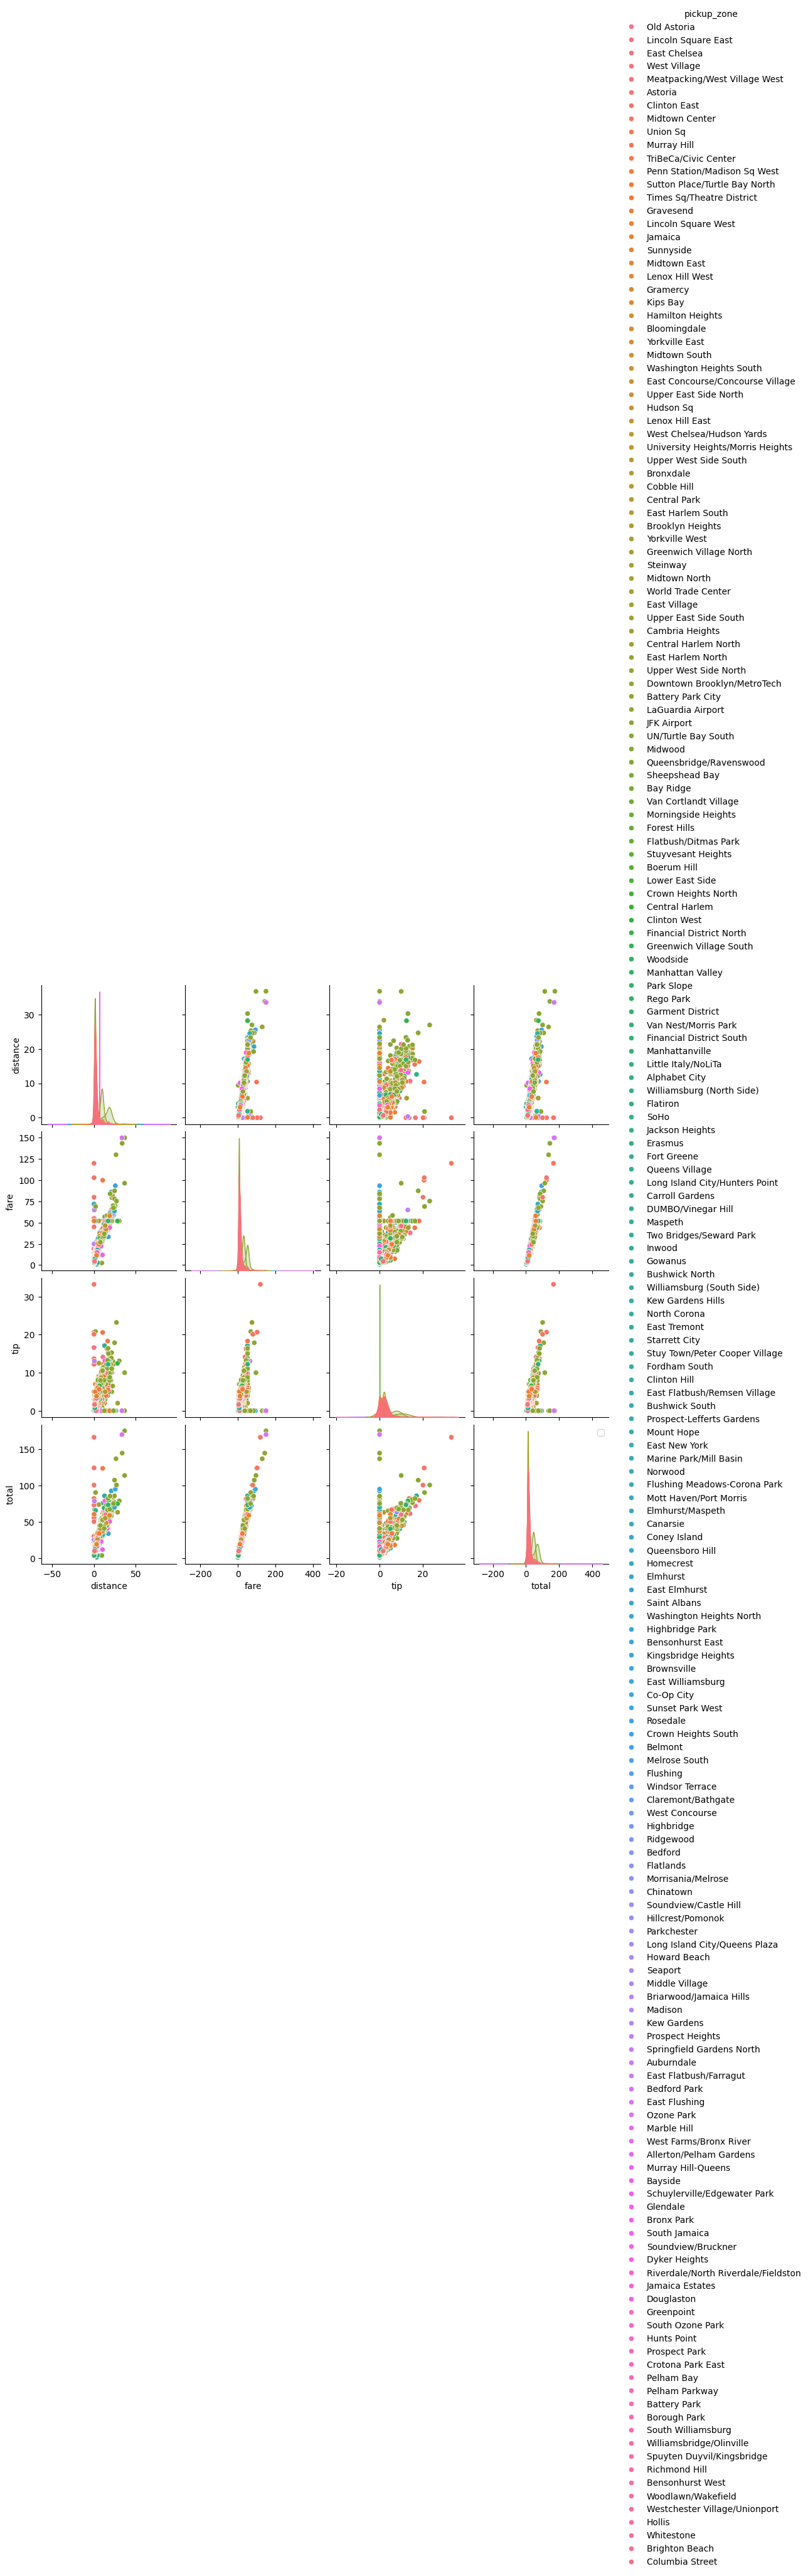

In [115]:
sns.pairplot(df, vars=['distance', 'fare', 'tip', 'total'], hue='pickup_zone')
plt.legend(bbox_to_anchor=(1,1))
plt.show()

### **★ Violin Plot**

/tmp/ipykernel_1469/1662615005.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='payment', y='fare',palette=['#800020','#4169E1'])


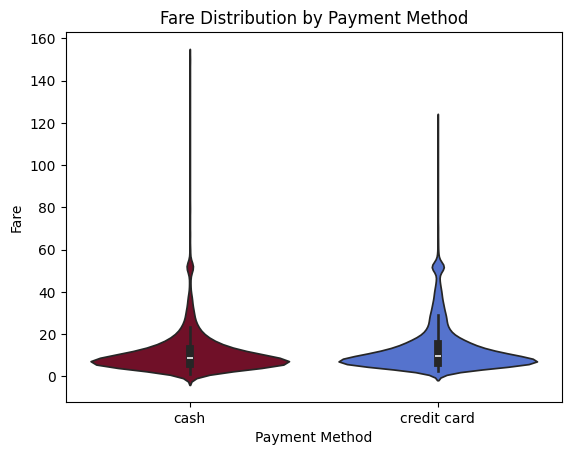

In [119]:
sns.violinplot(data=df, x='payment', y='fare',palette=['#800020','#4169E1'])

plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.show()